In [1]:
import numpy as np
from qutip import jmat, tensor, qeye, destroy
import cProfile
import pstats

from LiouvilleSpectroscopyV5 import LiouvilleSpectroscopySolver
from LiouvilleSpectroscopyV5 import SpectroscopyPlotter





In [2]:
def _stack_qutip_operator(op, N_k):
    """Convert a QuTiP operator to a complex NumPy stack with shape (N_k, d, d)."""
    dense = op.full().astype(np.complex128)
    return np.tile(dense, (N_k, 1, 1))


def build_holstein_H_mu(params, N_k=1):
    """Build the Hamiltonian and dipole operator with shape (N_k, d, d)."""
    Ee = params.get("Ee", 2.0)
    Ew = params.get("Ew", 0.2)
    J = params.get("J", 0.02)
    S = params.get("S", 1.0)
    n_phonons = params.get("n_phonons", 2)
    hbar = 0.658211951

    jz = jmat(1 / 2, "z")
    jm = jmat(1 / 2, "-")
    jp = jmat(1 / 2, "+")
    I2 = qeye(2)
    In = qeye(n_phonons)
    a = destroy(n_phonons) if n_phonons > 1 else 0 * In

    sz1 = tensor(jz, I2, I2, In, In, In)
    sz2 = tensor(I2, jz, I2, In, In, In)
    sz3 = tensor(I2, I2, jz, In, In, In)

    a1 = tensor(I2, I2, I2, a, In, In)
    a2 = tensor(I2, I2, I2, In, a, In)
    a3 = tensor(I2, I2, I2, In, In, a)

    sp1 = tensor(jp, I2, I2, In, In, In)
    sp2 = tensor(I2, jp, I2, In, In, In)
    sp3 = tensor(I2, I2, jp, In, In, In)

    sm1 = tensor(jm, I2, I2, In, In, In)
    sm2 = tensor(I2, jm, I2, In, In, In)
    sm3 = tensor(I2, I2, jm, In, In, In)

    H = (
        sz1 * (Ee / 2 + Ew * (a1.dag() * a1 + 0.5) + S * (a1.dag() + a1))
        + sz2 * (Ee / 2 + Ew * (a2.dag() * a2 + 0.5) + S * (a2.dag() + a2))
        + sz3 * (Ee / 2 + Ew * (a3.dag() * a3 + 0.5) + S * (a3.dag() + a3))
        + J * (sp1 * sm2 + sp1 * sm3 + sp2 * sm3 + sm1 * sp2 + sm1 * sp3 + sm2 * sp3)
    )
    H = H / hbar

    lowering = sm1 + sm2 + sm3
    mu = lowering.dag() + lowering

    return _stack_qutip_operator(H, N_k), _stack_qutip_operator(mu, N_k)


def build_holstein_lindblad_ops(params, N_k=1):
    """Build Lindblad operators as a list of (operator_stack, gamma) pairs."""
    n_phonons = params.get("n_phonons", 2)
    gamma_ex = params.get("gamma_ex", 0.1)
    gamma_vib = params.get("gamma_vib", 0.05)
    T = params.get("T", 200)
    Ee = params.get("Ee", 2.0)

    c_ops = []

    jm = jmat(1 / 2, "-")
    jp = jmat(1 / 2, "+")
    I2 = qeye(2)
    In = qeye(n_phonons)
    a = destroy(n_phonons) if n_phonons > 1 else 0 * In

    if gamma_ex > 0:
        kB = 8.617333262e-5
        kT = T * kB
        beta = 1 / kT if kT > 0 else np.inf
        n_th = 1 / (np.exp(Ee * beta) - 1) if kT > 0 else 0

        gamma_down = gamma_ex * (n_th + 1)
        gamma_up = gamma_ex * n_th

        sm1 = tensor(jm, I2, I2, In, In, In)
        sm2 = tensor(I2, jm, I2, In, In, In)
        sm3 = tensor(I2, I2, jm, In, In, In)

        c_ops.append((_stack_qutip_operator(sm1, N_k), gamma_down))
        c_ops.append((_stack_qutip_operator(sm2, N_k), gamma_down))
        c_ops.append((_stack_qutip_operator(sm3, N_k), gamma_down))

        if n_th > 0:
            sp1 = tensor(jp, I2, I2, In, In, In)
            sp2 = tensor(I2, jp, I2, In, In, In)
            sp3 = tensor(I2, I2, jp, In, In, In)

            c_ops.append((_stack_qutip_operator(sp1, N_k), gamma_up))
            c_ops.append((_stack_qutip_operator(sp2, N_k), gamma_up))
            c_ops.append((_stack_qutip_operator(sp3, N_k), gamma_up))

    if gamma_vib > 0 and n_phonons > 1:
        a1 = tensor(I2, I2, I2, a, In, In)
        a2 = tensor(I2, I2, I2, In, a, In)
        a3 = tensor(I2, I2, I2, In, In, a)

        c_ops.append((_stack_qutip_operator(a1, N_k), gamma_vib))
        c_ops.append((_stack_qutip_operator(a2, N_k), gamma_vib))
        c_ops.append((_stack_qutip_operator(a3, N_k), gamma_vib))

    return c_ops

--- Model loading (interaction type: dipole) ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.

--- 2D parallel benchmark context ---
Liouville backend      : dense
Hilbert dimension      : 8
Liouville dimension    : 64
k-points               : 40
omega points           : 100
omega grid             : 100 x 100 = 10000 omega pairs
tau2                   : 3.0
Eta                    : 0.05
BLAS threads limit     : 1
tested backends        : ('serial', 'threading')
tested n_jobs          : (1, 2, 3, 4, 5, 6)
block_size             : None
repeats                : 1
dense_liouville_cutoff : 512
-------------------------------------

         serial n_jobs=1   time=  69.836s speedup=  1.00x max_abs_diff=0.000e+00
      threading n_jobs=1   time=  75.974s speedup=  0.92x max_abs_diff=0.000e+00
      threading n_jobs=2   time=  65.689s speedup=  1.06x max_abs_diff=0.000e+00
      threading n_jobs=3   time=  57.502s speedup=  1.21x max_abs_diff=0.000e+00
      threading n

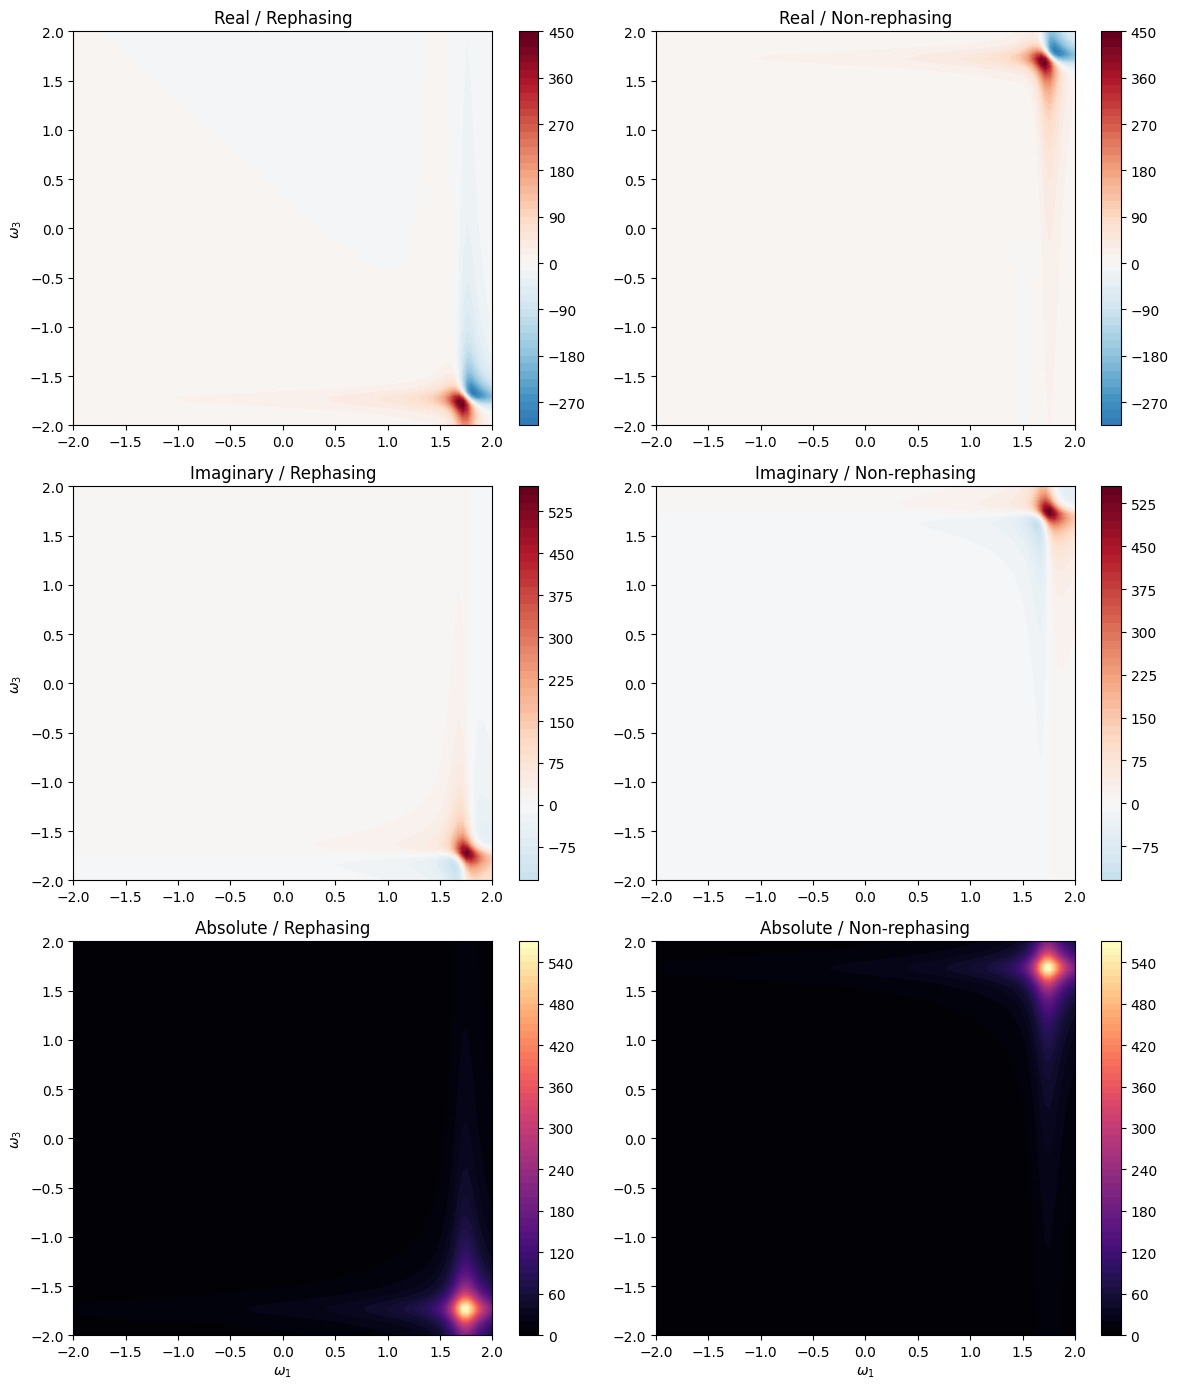

         8577388 function calls (8336536 primitive calls) in 524.991 seconds

   Ordered by: cumulative time
   List reduced from 2682 to 40 due to restriction <40>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      133    0.008    0.000  873.887    6.571 C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\asyncio\base_events.py:1980(_run_once)
       85    0.003    0.000  673.885    7.928 C:\Users\MathieuDesmarais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\parallel.py:1670(_get_outputs)
     26/4    0.000    0.000  521.831  130.458 C:\Users\MathieuDesmarais\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\text.py:73(_get_text_metrics_with_cache_impl)
        8    0.003    0.000  520.958   65.120 c:\Users\MathieuDesmarais\OneDrive - Univer

In [ ]:


TOTAL_KPOINTS = 50
k_array = np.linspace(-np.pi, np.pi, TOTAL_KPOINTS)

holstein_params = {
    "Ee": 2.0,
    "Ew": 0.2,
    "J": 0.02,
    "S": 1.0,
    "n_phonons": 1,
    "gamma_ex": 0.1,
    "gamma_vib": 0.05,
    "T": 200,
}



solver_params = {
    "Eta": 0.05,
    "T": holstein_params["T"],
    "mu": 0.0,
    "backend": "dense",
    "sparse_solver": "direct",
    "parallel_backend": "serial",
    "n_jobs": 1,
    "blas_threads": 1,
    "cache_resolvents": False,
    "cache_sparse_tau2": True,
    "sparse_gmres_rtol": 1e-6,
    "sparse_gmres_maxiter": 500,
}

H_array, mu_array = build_holstein_H_mu(holstein_params, N_k=TOTAL_KPOINTS)
c_ops_list = build_holstein_lindblad_ops(holstein_params, N_k=TOTAL_KPOINTS)

solver = LiouvilleSpectroscopySolver(solver_params)
solver.feed_model(
    H_model=H_array,
    interaction_op_array=mu_array,
    c_ops_raw=c_ops_list,
    interaction_type="dipole",
)

w_list = np.linspace(-2 , 2 , 100)


solver.benchmark_2D_parallel_backends(
    w_list,
    tau2=3.0,
    k_array=k_array,
    backends=("serial", "threading"),
    n_jobs_values=(1 , 2 , 3, 4 , 5 , 6),
    blas_threads=1,
)

spectra = solver.generate_2D_spectra(w_list, tau2=3.0, k_array=k_array)

plotter = SpectroscopyPlotter(w_list)
plotter.plot_spectrum(spectra["rephasing"], spectra["unrephasing"])


